In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the dataset
df =pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [3]:
#review top 5 rows
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [4]:
#Last five rows.
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [5]:
#Number of columns and rows
df.shape

(5190, 13)

In [6]:
#column names
df.columns.to_list()

['Unnamed: 0',
 'visits',
 'gender',
 'age',
 'income',
 'illness',
 'reduced',
 'health',
 'private',
 'freepoor',
 'freerepat',
 'nchronic',
 'lchronic']

In [7]:
#data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [8]:
#stastical info
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
visits,0
gender,0
age,0
income,0
illness,0
reduced,0
health,0
private,0
freepoor,0


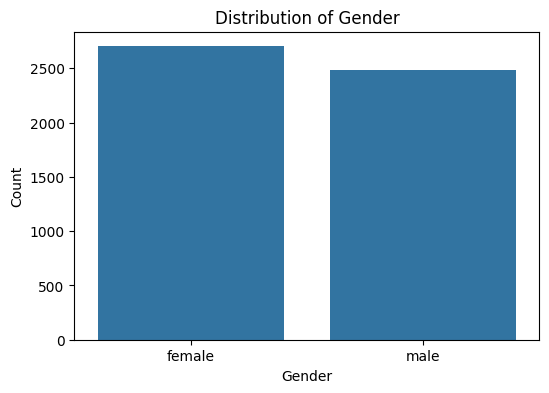

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

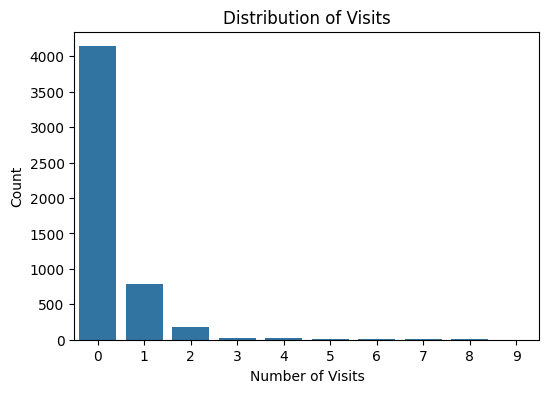

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='visits', data=df)
plt.title('Distribution of Visits')
plt.xlabel('Number of Visits')
plt.ylabel('Count')
plt.show()

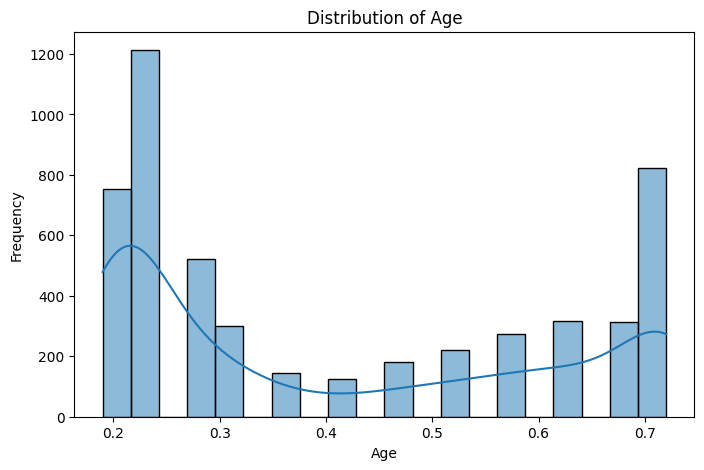

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Now, let's create some bivariate plots to explore relationships between variables.

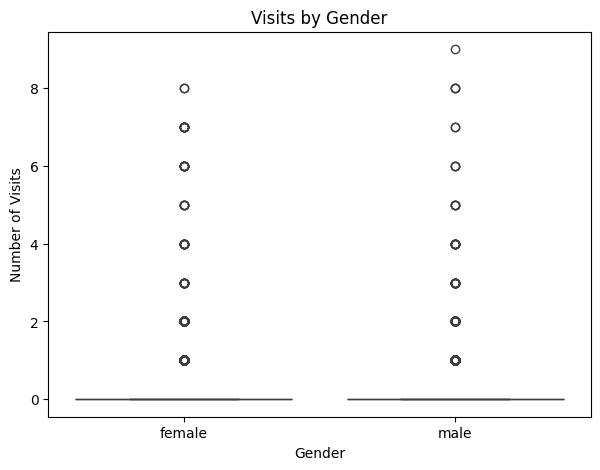

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='visits', data=df)
plt.title('Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Visits')
plt.show()

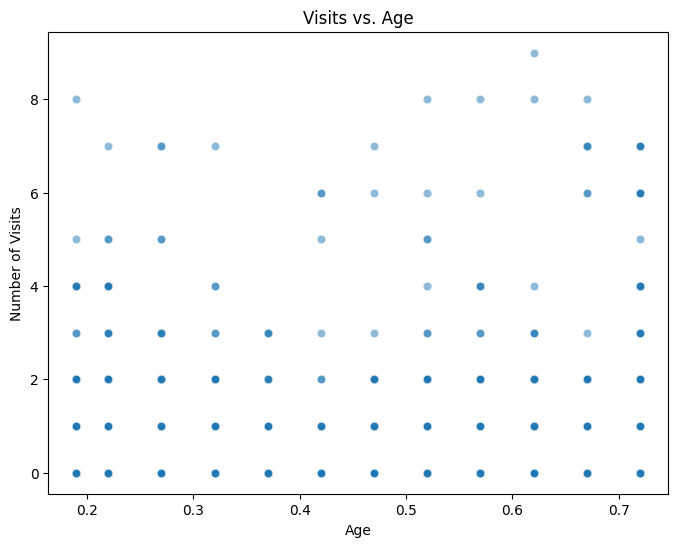

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='visits', data=df, alpha=0.5)
plt.title('Visits vs. Age')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.show()

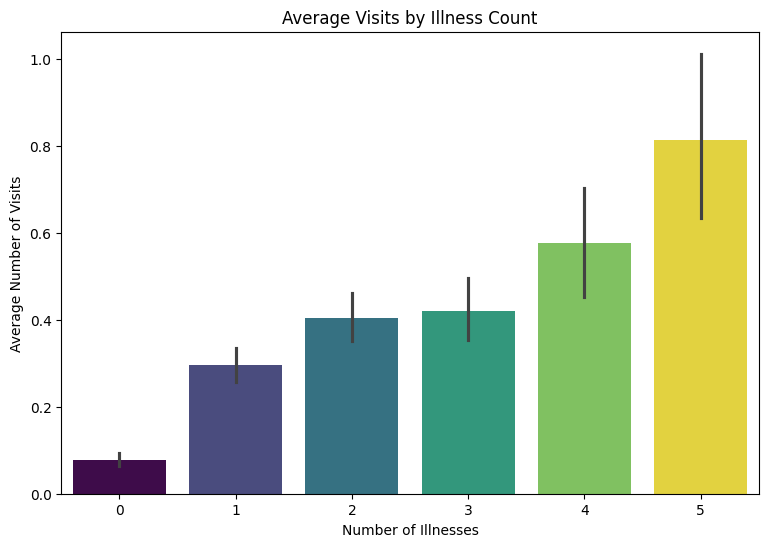

In [15]:
plt.figure(figsize=(9,6))
sns.barplot(x='illness', y='visits', data=df, palette='viridis', hue='illness', legend=False)
plt.title('Average Visits by Illness Count')
plt.xlabel('Number of Illnesses')
plt.ylabel('Average Number of Visits')
plt.show()

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


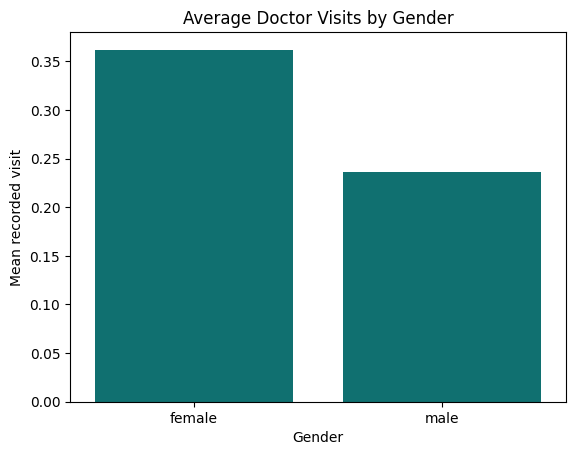

In [20]:
gender_analysis =( df.groupby("gender")["visits"].agg(["count","mean","median"]).reset_index())
display(gender_analysis)
sns.barplot(
    data=gender_analysis,
    x="gender",
    y="mean",
    color="teal"
)
plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean recorded visit")
plt.show()

,illness,count,mean
0,0,1554,0.078507
1,1,1638,0.295482
2,2,946,0.403805
3,3,542,0.420664
4,4,274,0.576642
5,5,236,0.813559


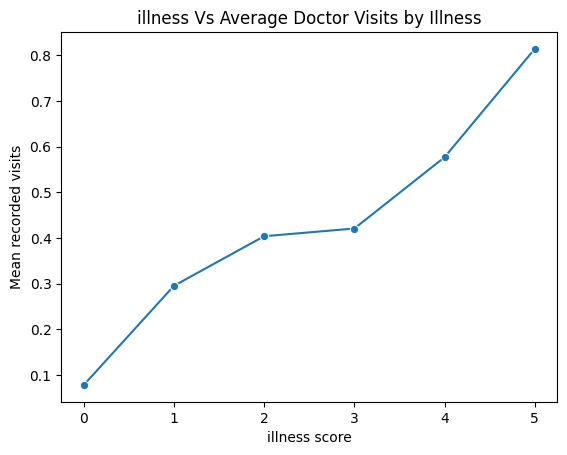

In [22]:
illness_analysis=(
    df.groupby("illness")["visits"].agg(["count","mean"]).reset_index()

)
display(illness_analysis)
sns.lineplot(
    data=illness_analysis,
    x="illness",
    y="mean",
    marker="o"
)
plt.title("illness Vs Average Doctor Visits by Illness")
plt.xlabel("illness score")
plt.ylabel("Mean recorded visits")
plt.show()

### Multivariate Plot 1: Visits vs. Age, Colored by Gender
This scatter plot helps visualize if the relationship between age and number of visits differs across genders.

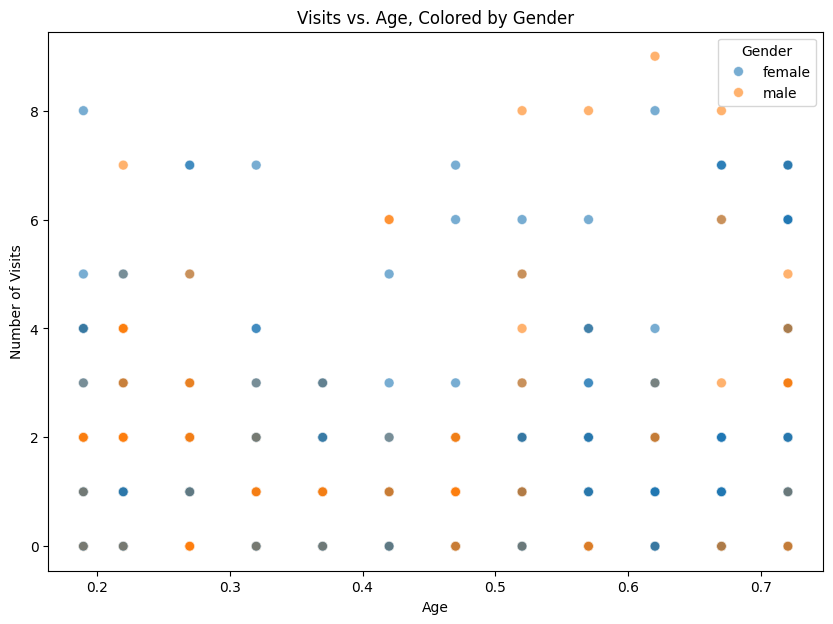

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='visits', hue='gender', data=df, alpha=0.6, s=50)
plt.title('Visits vs. Age, Colored by Gender')
plt.xlabel('Age')
plt.ylabel('Number of Visits')
plt.legend(title='Gender')
plt.show()

### Multivariate Plot 2: Visits by Private Insurance Status, Faceted by Gender
This plot uses box plots to compare the distribution of visits for individuals with and without private insurance, and further separates this comparison by gender.

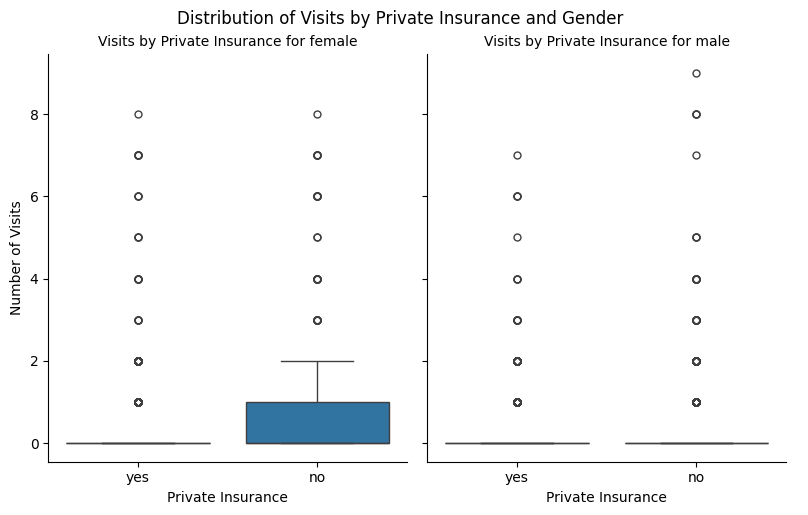

In [17]:
g = sns.catplot(x='private', y='visits', col='gender', data=df, kind='box', height=5, aspect=0.8)
g.set_axis_labels('Private Insurance', 'Number of Visits')
g.set_titles('Visits by Private Insurance for {col_name}')
plt.suptitle('Distribution of Visits by Private Insurance and Gender', y=1.02) # Adjust suptitle position
plt.show()

### Multivariate Plot 3: Average Visits by Illness Count, Grouped by Gender
This bar chart illustrates how the average number of visits changes with the number of illnesses, distinguishing between male and female patients.

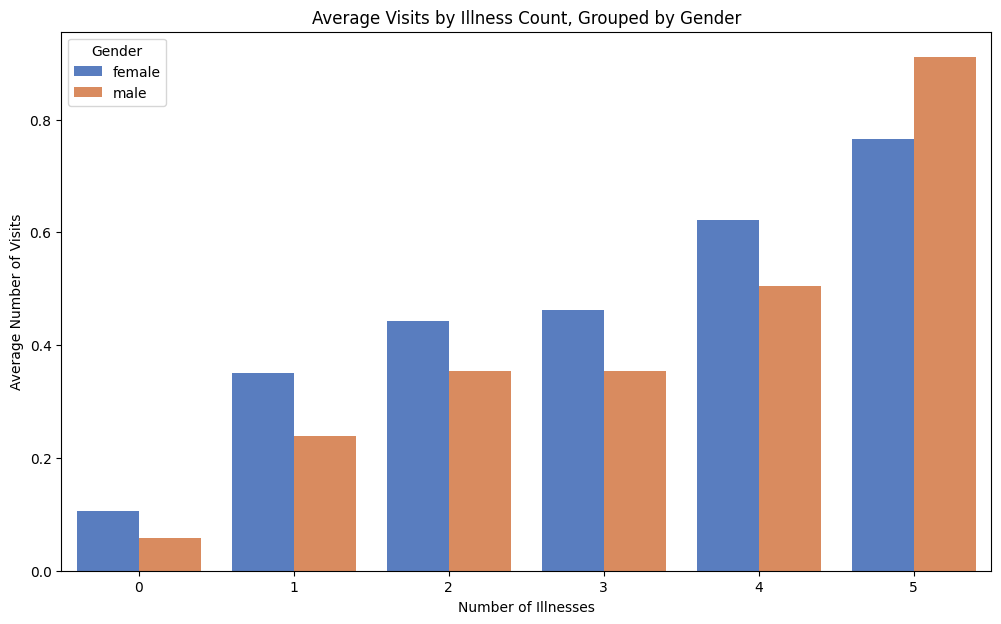

In [18]:
plt.figure(figsize=(12, 7))
sns.barplot(x='illness', y='visits', hue='gender', data=df, palette='muted', errorbar=None)
plt.title('Average Visits by Illness Count, Grouped by Gender')
plt.xlabel('Number of Illnesses')
plt.ylabel('Average Number of Visits')
plt.legend(title='Gender')
plt.show()